In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot_2samples

In [4]:
trait_info = {
    "50_irnt": "Standing Height",
    "30100_irnt": "Mean Platelet Volume",
    "30090_irnt": "Platelet Crit",
    "30210_irnt": "Eosinophill Percentage",
    "30010_irnt": "Red Blood Cell Count",
    "30190_irnt": "Monocyte Percentage",
}

In [8]:
def prepare_sim_data(df):
    df = df[df.freq > 0.01]
    df = df[df.pJ < 5e-8]

    return df["z"]

In [7]:
sim_data = {}
ukb_data = {}

In [9]:
for trait in trait_info:
    sim_data[trait] = prepare_sim_data(pd.read_csv(f"simulation_cojo_result/sim_{trait}_cojo_hit.csv"))
    ukb_data[trait] = pd.read_csv(f"simulation_cojo_result/sim_{trait}_cojo_hit.csv")["z"]

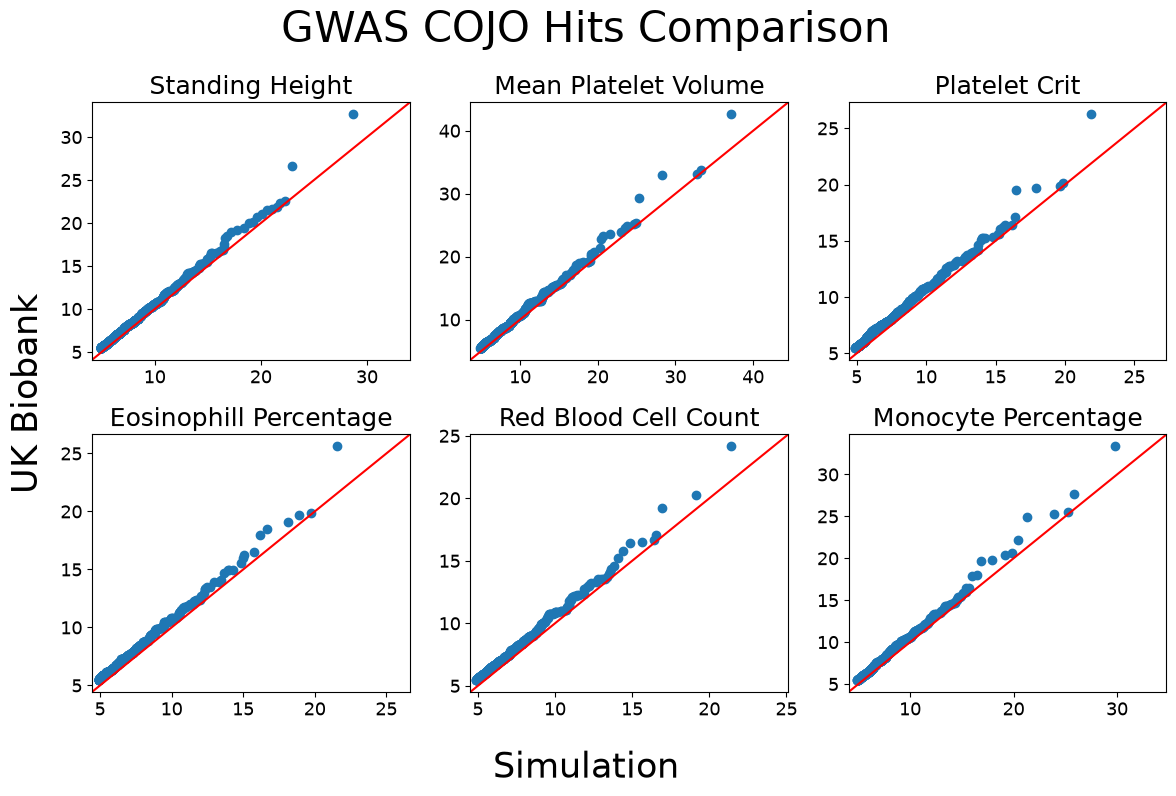

In [19]:
plt.rcParams.update({'font.size': 13})
fig, axes = plt.subplots(2, 3, tight_layout=True, figsize=(12, 8))
qqplot_2samples(sim_data["50_irnt"], ukb_data["50_irnt"], xlabel="", ylabel="", line="45", ax=axes[0,0])
axes[0,0].set_title(trait_info["50_irnt"], size=18)

qqplot_2samples(sim_data["30100_irnt"], ukb_data["30100_irnt"], xlabel="", ylabel="", line="45", ax=axes[0,1])
axes[0,1].set_title(trait_info["30100_irnt"], size=18)

qqplot_2samples(sim_data["30090_irnt"], ukb_data["30090_irnt"], xlabel="", ylabel="", line="45", ax=axes[0,2])
axes[0,2].set_title(trait_info["30090_irnt"], size=18)

qqplot_2samples(sim_data["30210_irnt"], ukb_data["30210_irnt"], xlabel="", ylabel="", line="45", ax=axes[1,0])
axes[1,0].set_title(trait_info["30210_irnt"], size=18)

qqplot_2samples(sim_data["30010_irnt"], ukb_data["30010_irnt"], xlabel="", ylabel="", line="45", ax=axes[1,1])
axes[1,1].set_title(trait_info["30010_irnt"], size=18)

qqplot_2samples(sim_data["30190_irnt"], ukb_data["30190_irnt"], xlabel="", ylabel="", line="45", ax=axes[1,2])
axes[1,2].set_title(trait_info["30190_irnt"], size=18)

fig.suptitle("GWAS COJO Hits Comparison", size=30)
fig.supxlabel("Simulation", size=25)
fig.supylabel("UK Biobank", size=25)
plt.savefig("gwas-cojo-hit-comparison.pdf")
plt.show()